# AxonScope — batch-only CPU vs GPU benchmark

This notebook runs only the **batch** mode for `N = 5, 50, 500, 1000`.

CPU and GPU run in separate subprocesses. Each timing is explicitly
synchronized before the timer stops. The final figure shows:

1. CPU and GPU median batch time;
2. GPU speed-up (`CPU time / GPU time`);
3. maximum and RMS CPU–GPU voltage-trace differences.

Select a GPU runtime first:

**Runtime → Change runtime type → Hardware accelerator → GPU**

In [18]:
# @title Install AxonScope and JAX only when needed
import json
import shutil
import subprocess
import sys
from pathlib import Path

REPO_DIR = Path("/content/AxonScope")
REPO_URL = "https://github.com/louisreg/AxonScope.git"
UPDATE_REPO = False  # @param {type:"boolean"}
FORCE_REINSTALL = False  # @param {type:"boolean"}
PROBE_SOURCE = 'import json\nresult = {"axonscope": False, "cpu": False, "gpu": False, "jax": None}\ntry:\n    import axonscope\n    result["axonscope"] = True\nexcept Exception:\n    pass\ntry:\n    import jax\n    result["jax"] = jax.__version__\n    try:\n        result["cpu"] = bool(jax.devices("cpu"))\n    except Exception:\n        pass\n    try:\n        result["gpu"] = bool(jax.devices("gpu"))\n    except Exception:\n        pass\nexcept Exception:\n    pass\nprint("__PROBE__" + json.dumps(result))'


def run(command):
    print("$", " ".join(map(str, command)))
    subprocess.run(list(map(str, command)), check=True)


def probe():
    process = subprocess.run(
        [sys.executable, "-c", PROBE_SOURCE],
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
    )
    for line in reversed(process.stdout.splitlines()):
        if line.startswith("__PROBE__"):
            return json.loads(line.removeprefix("__PROBE__"))
    return {"axonscope": False, "cpu": False, "gpu": False, "jax": None}


if shutil.which("nvidia-smi") is None:
    raise RuntimeError("No NVIDIA GPU is visible. Select a GPU runtime in Colab.")

before = probe()

if FORCE_REINSTALL or not before["gpu"]:
    command = [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "--upgrade",
    ]
    if FORCE_REINSTALL:
        command.append("--force-reinstall")
    command.append("jax[cuda12]")
    run(command)
else:
    print(f"✓ JAX {before['jax']} already has CPU and GPU support.")

fresh_clone = False
if not (REPO_DIR / ".git").exists():
    if REPO_DIR.exists():
        shutil.rmtree(REPO_DIR)
    run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR])
    fresh_clone = True
elif UPDATE_REPO:
    run(["git", "-C", REPO_DIR, "pull", "--ff-only"])
else:
    print("✓ AxonScope repository is already present.")

marker = REPO_DIR / ".colab_batch_cpu_gpu_installed"
if (
    FORCE_REINSTALL
    or fresh_clone
    or UPDATE_REPO
    or not marker.exists()
    or not before["axonscope"]
):
    command = [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "--upgrade",
    ]
    if FORCE_REINSTALL:
        command.append("--force-reinstall")
    command.extend(["-e", f"{REPO_DIR}[benchmark]"])
    run(command)
    marker.write_text("installed")
else:
    print("✓ AxonScope is already installed from this Colab VM.")

after = probe()
print("\nEnvironment:", after)
if not (after["axonscope"] and after["cpu"] and after["gpu"]):
    raise RuntimeError("AxonScope/JAX CPU/GPU setup is incomplete.")

✓ JAX 0.7.2 already has CPU and GPU support.
✓ AxonScope repository is already present.
✓ AxonScope is already installed from this Colab VM.

Environment: {'axonscope': True, 'cpu': True, 'gpu': True, 'jax': '0.7.2'}


In [19]:
# @title Write the benchmark script
from pathlib import Path

SCRIPT_SOURCE = '#!/usr/bin/env python3\n"""AxonScope batch-only CPU vs GPU benchmark.\n\nRuns one AxonScope ``simulate_pool`` batch for N fibers on CPU and GPU,\nfor N in 5, 50, 500, and 1000 by default.\n\nEach backend runs in a separate Python process so JAX backend selection is\nreliable. The script measures synchronized batch execution, compares CPU/GPU\nvoltage traces, writes CSV/JSON/NPZ outputs, and creates a summary figure.\n"""\n\nfrom __future__ import annotations\n\nimport argparse\nimport gc\nimport json\nimport os\nimport shutil\nimport subprocess\nimport sys\nfrom pathlib import Path\nfrom time import perf_counter\nfrom typing import Any\n\n\nDEFAULT_FIBER_COUNTS = (5, 50, 500, 1000)\n\n\ndef parse_args() -> argparse.Namespace:\n    parser = argparse.ArgumentParser(\n        description="Benchmark AxonScope batch execution on CPU versus GPU."\n    )\n    parser.add_argument(\n        "--fibers",\n        type=int,\n        nargs="+",\n        default=list(DEFAULT_FIBER_COUNTS),\n        help="Fiber counts to benchmark. Default: 5 50 500 1000.",\n    )\n    parser.add_argument("--repeats", type=int, default=3)\n    parser.add_argument("--duration-ms", type=float, default=20.0)\n    parser.add_argument("--dt-ms", type=float, default=0.01)\n    parser.add_argument("--length-um", type=float, default=100.0)\n    parser.add_argument("--diameter-um", type=float, default=0.5)\n    parser.add_argument("--compartments", type=int, default=51)\n    parser.add_argument("--y-min-um", type=float, default=10.0)\n    parser.add_argument("--y-max-um", type=float, default=250.0)\n    parser.add_argument(\n        "--output-dir",\n        type=Path,\n        default=Path("axonscope_batch_cpu_gpu_results"),\n    )\n    parser.add_argument("--skip-gpu", action="store_true")\n    parser.add_argument("--worker", choices=("cpu", "gpu"), default=None)\n    return parser.parse_args()\n\n\ndef validate_args(args: argparse.Namespace) -> None:\n    if not args.fibers or any(value < 1 for value in args.fibers):\n        raise ValueError("All fiber counts must be positive integers.")\n    if args.repeats < 1:\n        raise ValueError("--repeats must be >= 1.")\n    if args.duration_ms <= 0 or args.dt_ms <= 0:\n        raise ValueError("--duration-ms and --dt-ms must be positive.")\n    if args.compartments < 3:\n        raise ValueError("--compartments must be >= 3.")\n    if args.y_max_um <= args.y_min_um:\n        raise ValueError("--y-max-um must be greater than --y-min-um.")\n\n\ndef gpu_is_visible() -> bool:\n    if shutil.which("nvidia-smi") is None:\n        return False\n    process = subprocess.run(\n        ["nvidia-smi", "-L"],\n        stdout=subprocess.PIPE,\n        stderr=subprocess.DEVNULL,\n        text=True,\n    )\n    return process.returncode == 0 and bool(process.stdout.strip())\n\n\ndef build_worker_command(\n    script_file: Path,\n    backend: str,\n    args: argparse.Namespace,\n) -> list[str]:\n    return [\n        sys.executable,\n        str(script_file),\n        "--worker",\n        backend,\n        "--fibers",\n        *[str(value) for value in args.fibers],\n        "--repeats",\n        str(args.repeats),\n        "--duration-ms",\n        str(args.duration_ms),\n        "--dt-ms",\n        str(args.dt_ms),\n        "--length-um",\n        str(args.length_um),\n        "--diameter-um",\n        str(args.diameter_um),\n        "--compartments",\n        str(args.compartments),\n        "--y-min-um",\n        str(args.y_min_um),\n        "--y-max-um",\n        str(args.y_max_um),\n        "--output-dir",\n        str(args.output_dir),\n    ]\n\n\ndef run_worker_subprocess(\n    script_file: Path,\n    backend: str,\n    args: argparse.Namespace,\n) -> None:\n    env = os.environ.copy()\n    env["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"\n\n    if backend == "cpu":\n        env["JAX_PLATFORMS"] = "cpu"\n    else:\n        env.pop("JAX_PLATFORMS", None)\n        env.pop("JAX_PLATFORM_NAME", None)\n\n    command = build_worker_command(script_file, backend, args)\n    print("\\n" + "=" * 80)\n    print(f"STARTING {backend.upper()} WORKER")\n    print("=" * 80)\n    print("$", " ".join(command), flush=True)\n    subprocess.run(command, env=env, check=True)\n\n\ndef make_point_source_electrode(axs: Any, length: Any) -> Any:\n    current = axs.Stimulus.pulse(\n        start=0.10 * axs.ms,\n        duration=0.50 * axs.ms,\n        amplitude=-50.0 * axs.uA,\n    )\n    return axs.PointSourceElectrode(\n        x=length / 2.0,\n        y=0.0 * axs.um,\n        z=0.0 * axs.um,\n        stimulus=current,\n    )\n\n\ndef make_simulations(\n    axs: Any,\n    *,\n    count: int,\n    length: Any,\n    diameter_um: float,\n    compartments: int,\n    y_min_um: float,\n    y_max_um: float,\n) -> tuple[Any, ...]:\n    import numpy as np\n\n    electrode = make_point_source_electrode(axs, length)\n    y_positions = np.linspace(y_min_um, y_max_um, count) * axs.um\n    simulations: list[Any] = []\n\n    for index, y_position in enumerate(y_positions):\n        axon = axs.axons.RattayAberham(\n            length=length,\n            diameter=diameter_um * axs.um,\n            compartments=compartments,\n            celsius=37.0 * axs.degC,\n        )\n        simulation = axs.AxonInstance(axon)\n        simulation.add_extracellular_context(\n            context=axs.analytical.local_point_source_context(\n                electrode,\n                sigma=0.3 * axs.S_per_m,\n                axon_y=y_position,\n                axon_z=0.0 * axs.um,\n            )\n        )\n        simulation.label = f"fiber {index}"\n        simulations.append(simulation)\n\n    return tuple(simulations)\n\n\ndef synchronize_results(results: tuple[Any, ...]) -> None:\n    """Wait for JAX computation without timing NumPy host conversion."""\n    import numpy as np\n\n    for result in results:\n        vm = result.Vm\n        block_until_ready = getattr(vm, "block_until_ready", None)\n        if callable(block_until_ready):\n            block_until_ready()\n        else:\n            np.asarray(vm)\n\n\ndef extract_center_traces(\n    results: tuple[Any, ...],\n    axs: Any,\n) -> tuple[Any, Any]:\n    import numpy as np\n\n    traces: list[Any] = []\n    time_ms = None\n\n    for result in results:\n        current_time_ms, voltage_mV = result.trace_values(\n            index=0,\n            time_unit=axs.ms,\n            voltage_unit=axs.mV,\n        )\n        if time_ms is None:\n            time_ms = np.asarray(current_time_ms, dtype=float)\n        traces.append(np.asarray(voltage_mV, dtype=float))\n\n    if time_ms is None:\n        raise RuntimeError("The batch returned no simulation results.")\n\n    return time_ms, np.stack(traces, axis=0)\n\n\ndef run_batch_once(\n    axs: Any,\n    *,\n    simulations: tuple[Any, ...],\n    duration: Any,\n    dt: Any,\n    recording: Any,\n) -> tuple[Any, ...]:\n    return tuple(\n        axs.simulate_pool(\n            simulations,\n            duration=duration,\n            dt=dt,\n            recording=recording,\n        )\n    )\n\n\ndef worker_main(args: argparse.Namespace) -> None:\n    import numpy as np\n    import jax\n    import axonscope as axs\n\n    backend = args.worker\n    assert backend in {"cpu", "gpu"}\n\n    devices = jax.devices(backend)\n    if not devices:\n        raise RuntimeError(f"No JAX {backend} device is available.")\n    device = devices[0]\n\n    output_dir = args.output_dir.resolve()\n    output_dir.mkdir(parents=True, exist_ok=True)\n\n    length = args.length_um * axs.um\n    duration = args.duration_ms * axs.ms\n    dt = args.dt_ms * axs.ms\n    recording = axs.Recording.center(axs.signals.Vm)\n    rows: list[dict[str, Any]] = []\n\n    print(f"JAX version : {jax.__version__}")\n    print(f"Backend     : {backend}")\n    print(f"Device      : {device}")\n    print(f"Fiber counts: {args.fibers}")\n    print(f"Repeats     : {args.repeats}")\n\n    with jax.default_device(device):\n        for count in args.fibers:\n            print("\\n" + "-" * 80)\n            print(f"{backend.upper()} — N = {count}")\n            print("-" * 80)\n\n            warmup_simulations = make_simulations(\n                axs,\n                count=count,\n                length=length,\n                diameter_um=args.diameter_um,\n                compartments=args.compartments,\n                y_min_um=args.y_min_um,\n                y_max_um=args.y_max_um,\n            )\n            warmup_results = run_batch_once(\n                axs,\n                simulations=warmup_simulations,\n                duration=duration,\n                dt=dt,\n                recording=recording,\n            )\n            synchronize_results(warmup_results)\n            del warmup_results, warmup_simulations\n            gc.collect()\n\n            elapsed_seconds: list[float] = []\n            latest_results: tuple[Any, ...] | None = None\n\n            for repeat_index in range(args.repeats):\n                simulations = make_simulations(\n                    axs,\n                    count=count,\n                    length=length,\n                    diameter_um=args.diameter_um,\n                    compartments=args.compartments,\n                    y_min_um=args.y_min_um,\n                    y_max_um=args.y_max_um,\n                )\n                gc.collect()\n\n                start = perf_counter()\n                results = run_batch_once(\n                    axs,\n                    simulations=simulations,\n                    duration=duration,\n                    dt=dt,\n                    recording=recording,\n                )\n                synchronize_results(results)\n                elapsed = perf_counter() - start\n\n                elapsed_seconds.append(elapsed)\n                latest_results = results\n                print(\n                    f"repeat {repeat_index + 1}/{args.repeats}: "\n                    f"{elapsed * 1e3:.3f} ms"\n                )\n\n                del simulations\n                if repeat_index + 1 < args.repeats:\n                    del results\n                    gc.collect()\n\n            if latest_results is None:\n                raise RuntimeError("No timed result was produced.")\n\n            time_ms, traces_mV = extract_center_traces(latest_results, axs)\n            timings_ms = np.asarray(elapsed_seconds, dtype=float) * 1e3\n\n            npz_path = output_dir / f"{backend}_N{count}.npz"\n            np.savez_compressed(\n                npz_path,\n                time_ms=time_ms,\n                traces_mV=traces_mV,\n                timings_ms=timings_ms,\n            )\n\n            row = {\n                "backend": backend,\n                "device": str(device),\n                "jax_version": jax.__version__,\n                "fibers": count,\n                "repeats": args.repeats,\n                "median_ms": float(np.median(timings_ms)),\n                "min_ms": float(np.min(timings_ms)),\n                "max_ms": float(np.max(timings_ms)),\n                "mean_ms": float(np.mean(timings_ms)),\n                "std_ms": float(np.std(timings_ms)),\n                "npz": str(npz_path),\n            }\n            rows.append(row)\n\n            print(f"median: {row[\'median_ms\']:.3f} ms")\n            print(f"saved : {npz_path}")\n\n            del latest_results, traces_mV\n            gc.collect()\n\n    summary_path = output_dir / f"{backend}_summary.json"\n    summary_path.write_text(json.dumps(rows, indent=2))\n    print(f"\\n{backend.upper()} summary: {summary_path}")\n\n\ndef compare_and_plot(args: argparse.Namespace) -> None:\n    import numpy as np\n    import pandas as pd\n    import matplotlib.pyplot as plt\n\n    output_dir = args.output_dir.resolve()\n    cpu_rows = json.loads((output_dir / "cpu_summary.json").read_text())\n\n    if args.skip_gpu:\n        dataframe = pd.DataFrame(cpu_rows)\n        dataframe.to_csv(output_dir / "benchmark_summary.csv", index=False)\n        print(dataframe.to_string(index=False))\n        return\n\n    gpu_rows = json.loads((output_dir / "gpu_summary.json").read_text())\n    cpu_by_n = {int(row["fibers"]): row for row in cpu_rows}\n    gpu_by_n = {int(row["fibers"]): row for row in gpu_rows}\n    comparison_rows: list[dict[str, Any]] = []\n\n    for count in args.fibers:\n        cpu_data = np.load(output_dir / f"cpu_N{count}.npz")\n        gpu_data = np.load(output_dir / f"gpu_N{count}.npz")\n\n        cpu_time = np.asarray(cpu_data["time_ms"], dtype=float)\n        gpu_time = np.asarray(gpu_data["time_ms"], dtype=float)\n        cpu_traces = np.asarray(cpu_data["traces_mV"], dtype=float)\n        gpu_traces = np.asarray(gpu_data["traces_mV"], dtype=float)\n\n        if cpu_traces.shape != gpu_traces.shape:\n            raise RuntimeError(\n                f"N={count}: CPU/GPU shapes differ: "\n                f"{cpu_traces.shape} vs {gpu_traces.shape}."\n            )\n        if cpu_time.shape != gpu_time.shape or not np.allclose(\n            cpu_time,\n            gpu_time,\n            rtol=0.0,\n            atol=1e-12,\n        ):\n            raise RuntimeError(f"N={count}: CPU/GPU time vectors differ.")\n\n        difference = cpu_traces - gpu_traces\n        absolute_difference = np.abs(difference)\n        cpu_median_ms = float(cpu_by_n[count]["median_ms"])\n        gpu_median_ms = float(gpu_by_n[count]["median_ms"])\n\n        comparison_rows.append(\n            {\n                "fibers": count,\n                "cpu_median_ms": cpu_median_ms,\n                "gpu_median_ms": gpu_median_ms,\n                "cpu_over_gpu_speedup_x": cpu_median_ms / gpu_median_ms,\n                "max_abs_trace_diff_mV": float(np.max(absolute_difference)),\n                "mean_abs_trace_diff_mV": float(np.mean(absolute_difference)),\n                "rms_trace_diff_mV": float(np.sqrt(np.mean(np.square(difference)))),\n            }\n        )\n\n    dataframe = pd.DataFrame(comparison_rows).sort_values("fibers")\n    csv_path = output_dir / "benchmark_summary.csv"\n    json_path = output_dir / "benchmark_summary.json"\n    figure_path = output_dir / "batch_cpu_vs_gpu.png"\n\n    dataframe.to_csv(csv_path, index=False)\n    json_path.write_text(dataframe.to_json(orient="records", indent=2))\n\n    fiber_counts = dataframe["fibers"].to_numpy(dtype=int)\n    figure, axes = plt.subplots(1, 3, figsize=(17, 4.8))\n\n    axes[0].plot(fiber_counts, dataframe["cpu_median_ms"], marker="o", label="CPU")\n    axes[0].plot(fiber_counts, dataframe["gpu_median_ms"], marker="o", label="GPU")\n    axes[0].set_xscale("log")\n    axes[0].set_yscale("log")\n    axes[0].set_xticks(fiber_counts, [str(value) for value in fiber_counts])\n    axes[0].set_xlabel("Number of fibers")\n    axes[0].set_ylabel("Median synchronized batch time [ms]")\n    axes[0].set_title("Batch runtime")\n    axes[0].grid(True, which="both", alpha=0.3)\n    axes[0].legend()\n\n    axes[1].plot(\n        fiber_counts,\n        dataframe["cpu_over_gpu_speedup_x"],\n        marker="o",\n    )\n    axes[1].axhline(1.0, linestyle="--", linewidth=1)\n    axes[1].set_xscale("log")\n    axes[1].set_xticks(fiber_counts, [str(value) for value in fiber_counts])\n    axes[1].set_xlabel("Number of fibers")\n    axes[1].set_ylabel("CPU time / GPU time [×]")\n    axes[1].set_title("GPU speed-up")\n    axes[1].grid(True, which="both", alpha=0.3)\n\n    axes[2].plot(\n        fiber_counts,\n        dataframe["max_abs_trace_diff_mV"],\n        marker="o",\n        label="Maximum absolute difference",\n    )\n    axes[2].plot(\n        fiber_counts,\n        dataframe["rms_trace_diff_mV"],\n        marker="o",\n        label="RMS difference",\n    )\n    axes[2].set_xscale("log")\n    differences = dataframe[\n        ["max_abs_trace_diff_mV", "rms_trace_diff_mV"]\n    ].to_numpy()\n    if np.any(differences > 0):\n        axes[2].set_yscale("log")\n    axes[2].set_xticks(fiber_counts, [str(value) for value in fiber_counts])\n    axes[2].set_xlabel("Number of fibers")\n    axes[2].set_ylabel("|CPU − GPU| [mV]")\n    axes[2].set_title("Numerical trace difference")\n    axes[2].grid(True, which="both", alpha=0.3)\n    axes[2].legend(fontsize=8)\n\n    figure.suptitle("AxonScope batch-only CPU vs GPU benchmark", fontsize=14)\n    figure.tight_layout()\n    figure.savefig(figure_path, dpi=160, bbox_inches="tight")\n    plt.close(figure)\n\n    print("\\n" + "=" * 100)\n    print("FINAL COMPARISON")\n    print("=" * 100)\n    print(dataframe.to_string(index=False))\n    print(f"\\nCSV   : {csv_path}")\n    print(f"JSON  : {json_path}")\n    print(f"Figure: {figure_path}")\n\n\ndef parent_main(args: argparse.Namespace) -> None:\n    args.output_dir.mkdir(parents=True, exist_ok=True)\n    script_file = Path(__file__).resolve()\n\n    if not args.skip_gpu and not gpu_is_visible():\n        raise RuntimeError(\n            "No NVIDIA GPU is visible. In Colab, select "\n            "Runtime > Change runtime type > GPU."\n        )\n\n    run_worker_subprocess(script_file, "cpu", args)\n    if not args.skip_gpu:\n        run_worker_subprocess(script_file, "gpu", args)\n    compare_and_plot(args)\n\n\ndef main() -> None:\n    args = parse_args()\n    validate_args(args)\n    if args.worker is None:\n        parent_main(args)\n    else:\n        worker_main(args)\n\n\nif __name__ == "__main__":\n    main()\n'
script_file = Path("/content/axonscope_batch_cpu_vs_gpu.py")
script_file.write_text(SCRIPT_SOURCE)
script_file.chmod(0o755)
print("Script written to:", script_file)


Script written to: /content/axonscope_batch_cpu_vs_gpu.py


In [20]:
# @title Run batch CPU vs GPU for N = 5, 50, 500, 1000
import subprocess
import sys

command = [
    sys.executable,
    "/content/axonscope_batch_cpu_vs_gpu.py",
    "--fibers", "5", "50","200",
    "--repeats", "1",
    "--output-dir", "/content/axonscope_batch_cpu_gpu_results",
]
print("$", " ".join(command))
subprocess.run(command, check=True)

$ /usr/bin/python3 /content/axonscope_batch_cpu_vs_gpu.py --fibers 5 50 200 --repeats 1 --output-dir /content/axonscope_batch_cpu_gpu_results


CompletedProcess(args=['/usr/bin/python3', '/content/axonscope_batch_cpu_vs_gpu.py', '--fibers', '5', '50', '200', '--repeats', '1', '--output-dir', '/content/axonscope_batch_cpu_gpu_results'], returncode=0)

,fibers,cpu_median_ms,gpu_median_ms,cpu_over_gpu_speedup_x,max_abs_trace_diff_mV,mean_abs_trace_diff_mV,rms_trace_diff_mV
0,5,116.254432,234.864148,0.494986,0.012047,0.002616,0.003500
1,50,1954.983604,1559.197273,1.253840,0.068134,0.001671,0.002188
2,200,13393.983454,13552.919709,0.988273,0.139877,0.001684,0.002273


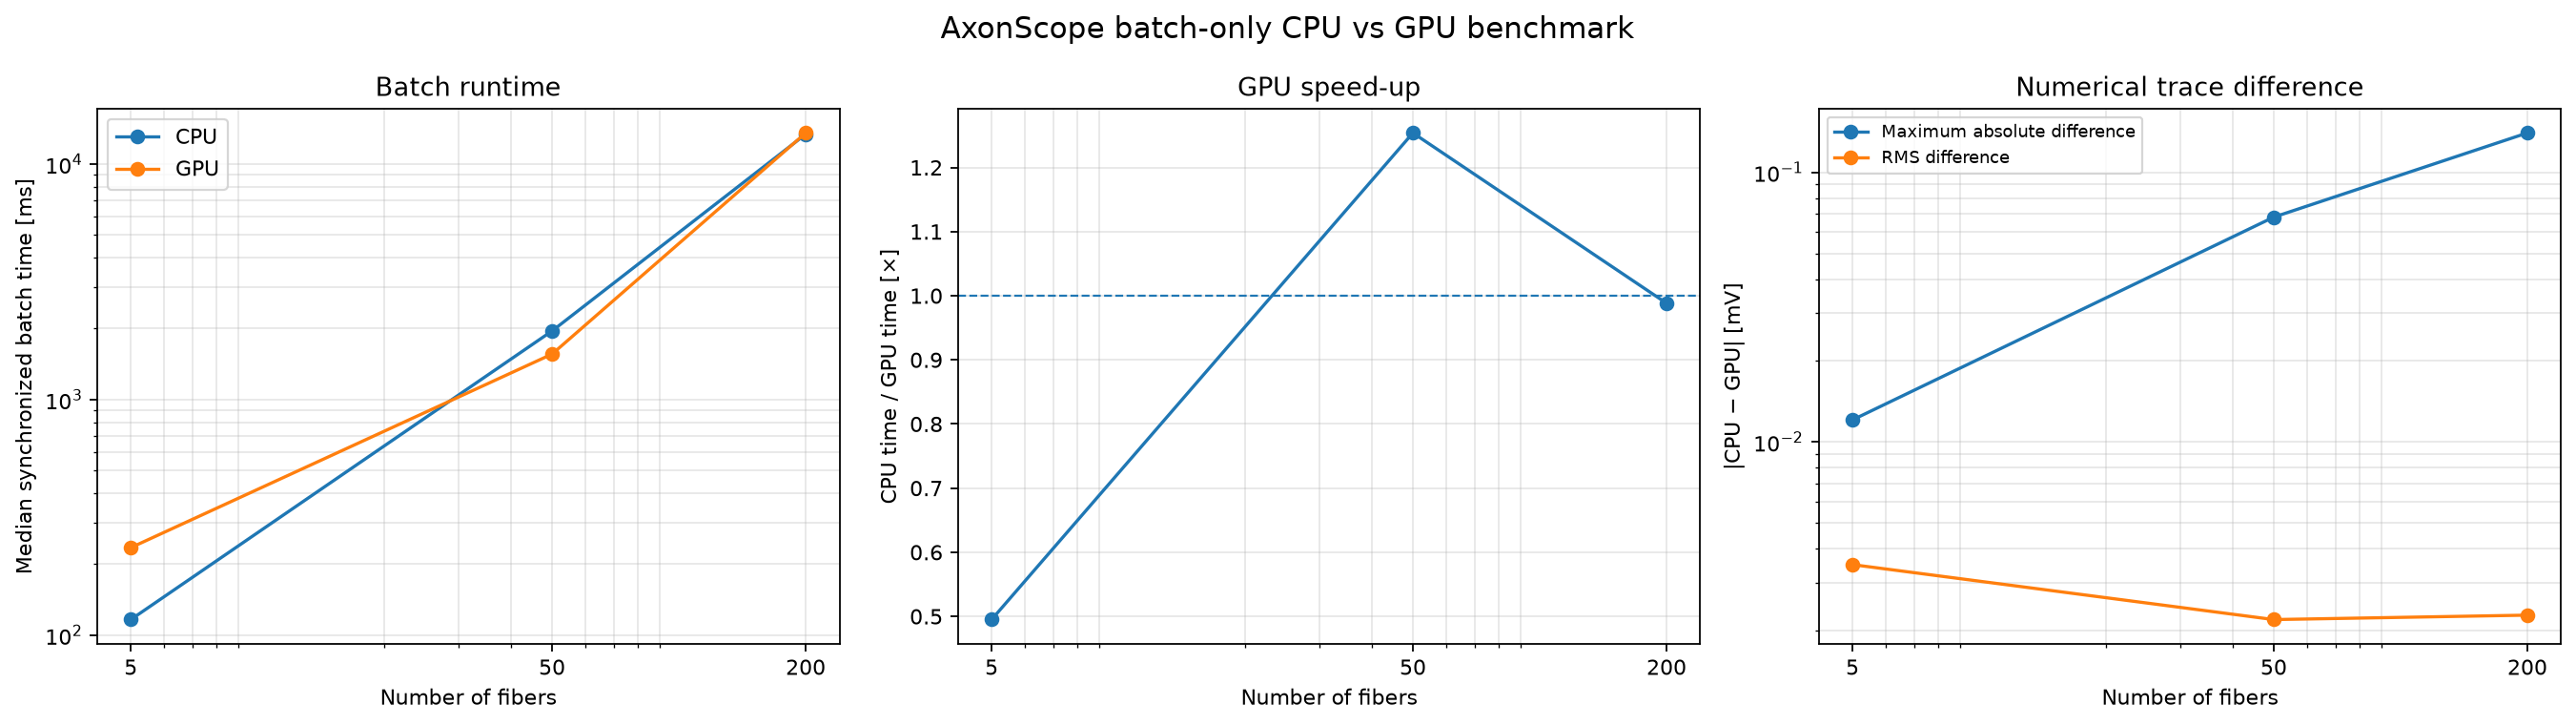

In [21]:
# @title Display the table and plots
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

result_dir = Path("/content/axonscope_batch_cpu_gpu_results")
display(pd.read_csv(result_dir / "benchmark_summary.csv"))
display(Image(filename=str(result_dir / "batch_cpu_vs_gpu.png")))

In [22]:
# @title Download all outputs
import shutil

archive = shutil.make_archive(
    "/content/axonscope_batch_cpu_gpu_results",
    "zip",
    root_dir="/content/axonscope_batch_cpu_gpu_results",
)
print("Created:", archive)

try:
    from google.colab import files
    files.download(archive)
except ImportError:
    pass

Created: /content/axonscope_batch_cpu_gpu_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>